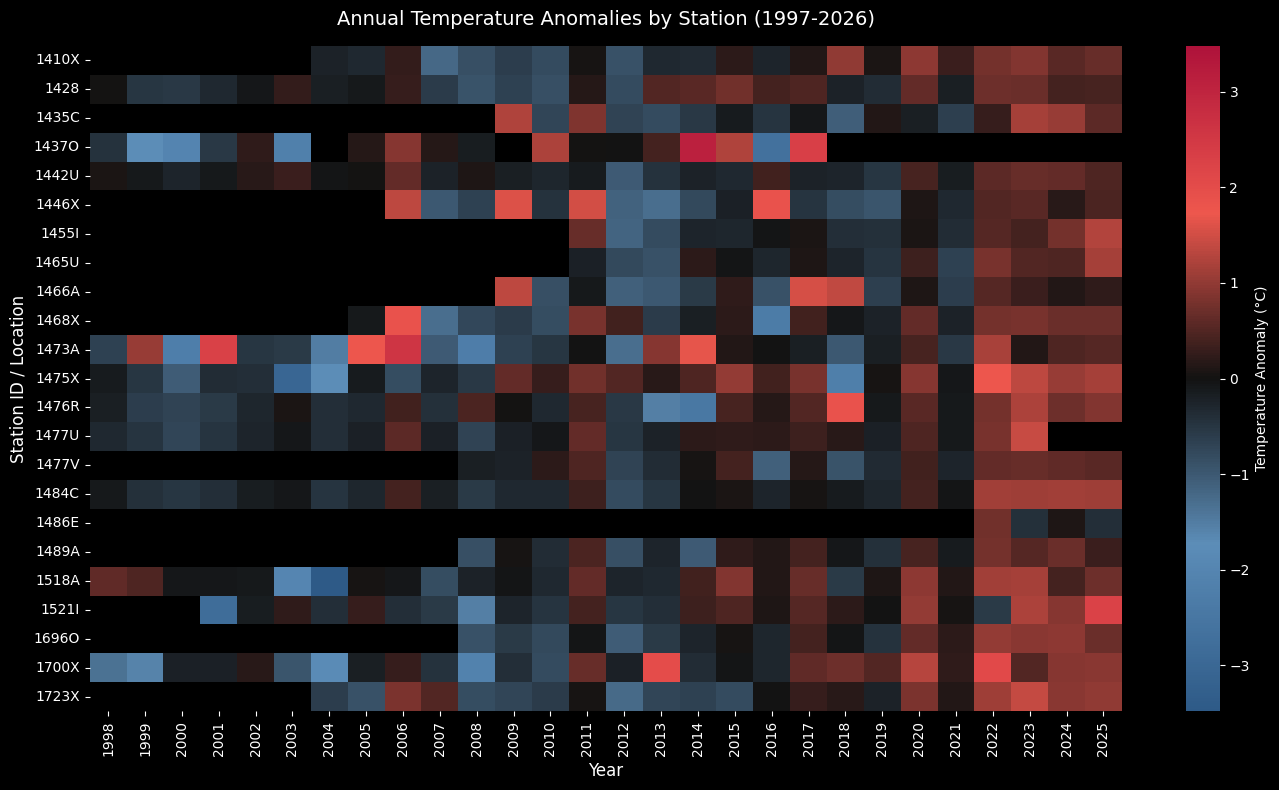

In [5]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load your spreadsheet
df = pd.read_excel("/galicia_tm_mes_1997_2026_v2.xlsx")

# 2. Filter for the requested years
df = df[(df["year"] >= 1998) & (df["year"] <= 2025)]

# 3. Reshape from wide format (months as columns) to long format
month_columns = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
df_long = pd.melt(
    df,
    id_vars=["year", "station_id"],
    value_vars=month_columns,
    var_name="month",
    value_name="temperature",
)

# 4. Calculate the annual average temperature for each station in each year
annual_station_temp = (
    df_long.groupby(["station_id", "year"])["temperature"]
    .mean()
    .reset_index()
)

# 5. Calculate the baseline historical average (1997-2026) FOR EACH STATION
station_baseline = (
    annual_station_temp.groupby("station_id")["temperature"]
    .mean()
    .reset_index()
)
station_baseline.rename(
    columns={"temperature": "baseline_temp"}, inplace=True
)

# Merge the baseline back into our annual data
plot_data = pd.merge(annual_station_temp, station_baseline, on="station_id")

# 6. Calculate the anomaly from that station's own historical average
plot_data["anomaly"] = plot_data["temperature"] - plot_data["baseline_temp"]

# 7. Pivot the data: Station ID on Y-axis (index), Years on X-axis (columns)
pivot = plot_data.pivot_table(
    values="anomaly", index="station_id", columns="year"
)

# --- CUSTOM COLOUR GRADIENT LOGIC ---
# We define a steep gradient: deep vibrant blue -> electric cyan -> dark center -> orange -> deep red
#gradient_colors = ["#2E5A87", "#5C8DB8", "#9AC4E1", "#121212", "#FDAC9D", "#EE574D", "#AE123A"]
gradient_colors = ["#2E5A87", "#5C8DB8", "#121212", "#EE574D", "#AE123A"]

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "dark_center_diverging", gradient_colors
)

# 8. Plot the heatmap
plt.style.use('dark_background')  # Sets background to black and text/ticks to white
plt.figure(figsize=(14, 8))

# Find the maximum absolute deviation to ensure 0 stays locked perfectly in the dark center
max_val = plot_data["anomaly"].abs().max()

sns.heatmap(
    pivot,
    cmap=custom_cmap,
    center=0,
    vmin=-max_val,
    vmax=max_val,
    cbar_kws={"label": "Temperature Anomaly (°C)"},
    linecolor="#222222",  # Subtle dark borders between grid squares
)

plt.title(
    "Annual Temperature Anomalies by Station (1997-2026)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Station ID / Location", fontsize=12)

plt.tight_layout()
plt.show()

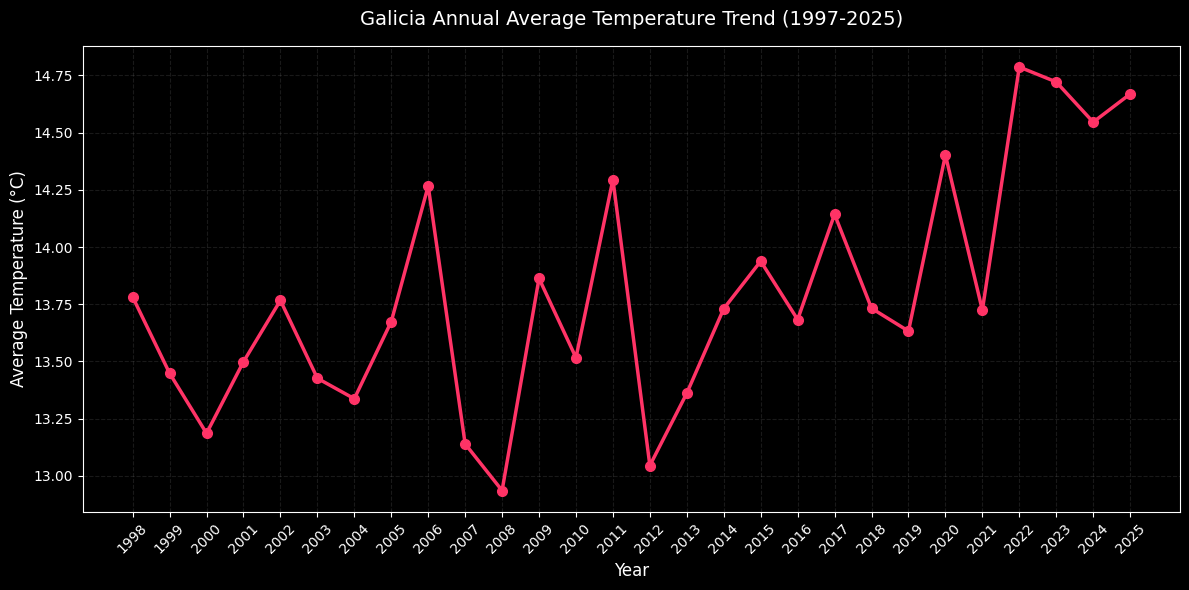

In [6]:
#Calculate the annual average temperature across all stations and all months for each year
annual_trend = df_long.groupby("year")["temperature"].mean().reset_index()

# 5. Plot the graph
plt.figure(figsize=(12, 6))

# Plotting a vibrant neon-style line to stand out against the black background
plt.plot(
    annual_trend["year"],
    annual_trend["temperature"],
    color="#ff3366",  # Bright cyan line
    linestyle="-",
    linewidth=2.5,
    marker="o",  # Circular markers at each year
    markersize=7,
    markerfacecolor="#ff3366",
    markeredgewidth=1,
    label="Annual Mean Temp",
)

# 6. Formatting the plot
plt.title(
    "Galicia Annual Average Temperature Trend (1997-2025)",
    fontsize=14,
    pad=15,
    color="white",
)
plt.xlabel("Year", fontsize=12, color="white")
plt.ylabel("Average Temperature (°C)", fontsize=12, color="white")

# Configure a subtle grid that looks good on dark backgrounds
plt.grid(True, linestyle="--", alpha=0.2, color="gray")

# Ensure all year labels show up nicely on the X-axis
plt.xticks(annual_trend["year"], rotation=45)

plt.tight_layout()
plt.show()

<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:114: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:114: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_681/4261219882.py:102: SyntaxWarning: invalid escape sequence '\c'
  s="1$^\circ$C",
/tmp/ipykernel_681/4261219882.py:114: SyntaxWarning: invalid escape sequence '\c'
  s=f"Rate of Increase: {slope:+.4f}$^\circ$C / year",


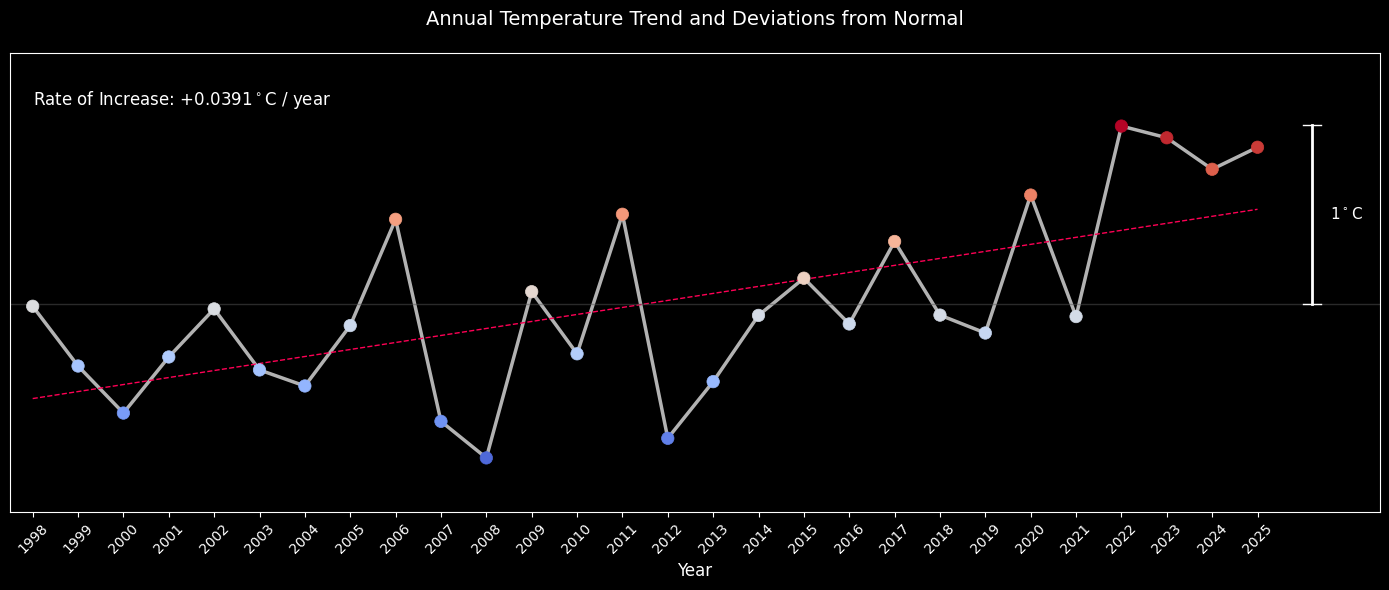

In [17]:
import numpy as np

annual_trend = df_long.groupby("year")["temperature"].mean().reset_index()

# 5. Calculate the overall historical baseline mean across all years
overall_mean = annual_trend["temperature"].mean()

# 6. Calculate the deviation (height from the baseline)
annual_trend["anomaly"] = annual_trend["temperature"] - overall_mean

# 7. Calculate the linear trendline using numpy
# slope (m) represents the rate of annual change, intercept (c) is the baseline shift
slope, intercept = np.polyfit(
    annual_trend["year"], annual_trend["temperature"], 1
)
trendline_y = slope * annual_trend["year"] + intercept

# 8. Set up color mapping based on the size of the anomaly for the data points
max_abs_anomaly = annual_trend["anomaly"].abs().max()
norm = mcolors.Normalize(vmin=-max_abs_anomaly, vmax=max_abs_anomaly)
cmap = plt.get_cmap("coolwarm")
colors = [cmap(norm(val)) for val in annual_trend["anomaly"]]

# 9. Plot the line graph
plt.figure(figsize=(14, 6))

# Plot the underlying connection line
plt.plot(
    annual_trend["year"],
    annual_trend["temperature"],
    color="#ffffff",
    linestyle="-",
    linewidth=2.5,
    alpha=0.7,
    zorder=1,
)

# Overlay the scatter points colored by their anomaly value
plt.scatter(
    annual_trend["year"],
    annual_trend["temperature"],
    color=colors,
    s=80,
    linewidths=0.5,
    zorder=3,
)

# Plot linear trendline
plt.plot(
    annual_trend["year"],
    trendline_y,
    color="#ff0055",
    linestyle="--",
    linewidth=1,
    label="Trendline",
    zorder=2,
)

# 10. Formatting the plot
plt.title(
    "Annual Temperature Trend and Deviations from Normal",
    fontsize=14,
    pad=20
)
plt.xlabel("Year", fontsize=12)

# Explicitly style the baseline line at the overall mean
plt.axhline(overall_mean, color="#555555", linestyle="-", linewidth=1.0, alpha=0.5)

# Position variables for the vertical 1°C scale indicator
scale_x = annual_trend["year"].max() + 1.2
scale_y_bottom = overall_mean
scale_y_top = overall_mean + 1.0

# Draw vertical indicator line
plt.plot(
    [scale_x, scale_x],
    [scale_y_bottom, scale_y_top],
    color="white",
    linestyle="-",
    linewidth=2,
)

# Add small cap ticks to the top and bottom of the vertical line
plt.plot(
    [scale_x - 0.2, scale_x + 0.2],
    [scale_y_bottom, scale_y_bottom],
    color="white",
    linewidth=1,
)
plt.plot(
    [scale_x - 0.2, scale_x + 0.2],
    [scale_y_top, scale_y_top],
    color="white",
    linewidth=1,
)

# Label the scale bar
plt.text(
    x=scale_x + 0.4,
    y=(scale_y_bottom + scale_y_top) / 2,
    s="1$^\circ$C",
    color="white",
    va="center",
    ha="left",
    fontsize=11,
)

# Add text label with the rate of average annual increase
# Displayed in the top left corner of the chart canvas
plt.text(
    x=annual_trend["year"].min(),
    y=max(annual_trend["temperature"].max() + 0.2, overall_mean + 1.2),
    s=f"Rate of Increase: {slope:+.4f}$^\circ$C / year",
    color="#ffffff",
    fontsize=12,
    va="top",
    ha="left",
)

# Clean up axes: Remove traditional Y-axis text labels and tick marks
plt.ylabel("")
plt.gca().get_yaxis().set_ticks([])

# Ensure all year labels show up nicely on x-axis
plt.xticks(annual_trend["year"], rotation=45)
plt.xlim(annual_trend["year"].min() - 0.5, scale_x + 1.5)

# Adjust y-limits to give breathing room
plt.ylim(
    min(annual_trend["temperature"].min() - 0.3, overall_mean - 0.5),
    max(annual_trend["temperature"].max() + 0.4, overall_mean + 1.4),
)

plt.tight_layout()
plt.show()

<>:73: SyntaxWarning: invalid escape sequence '\c'
<>:73: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_681/2294839655.py:73: SyntaxWarning: invalid escape sequence '\c'
  s="1$^\circ$C",


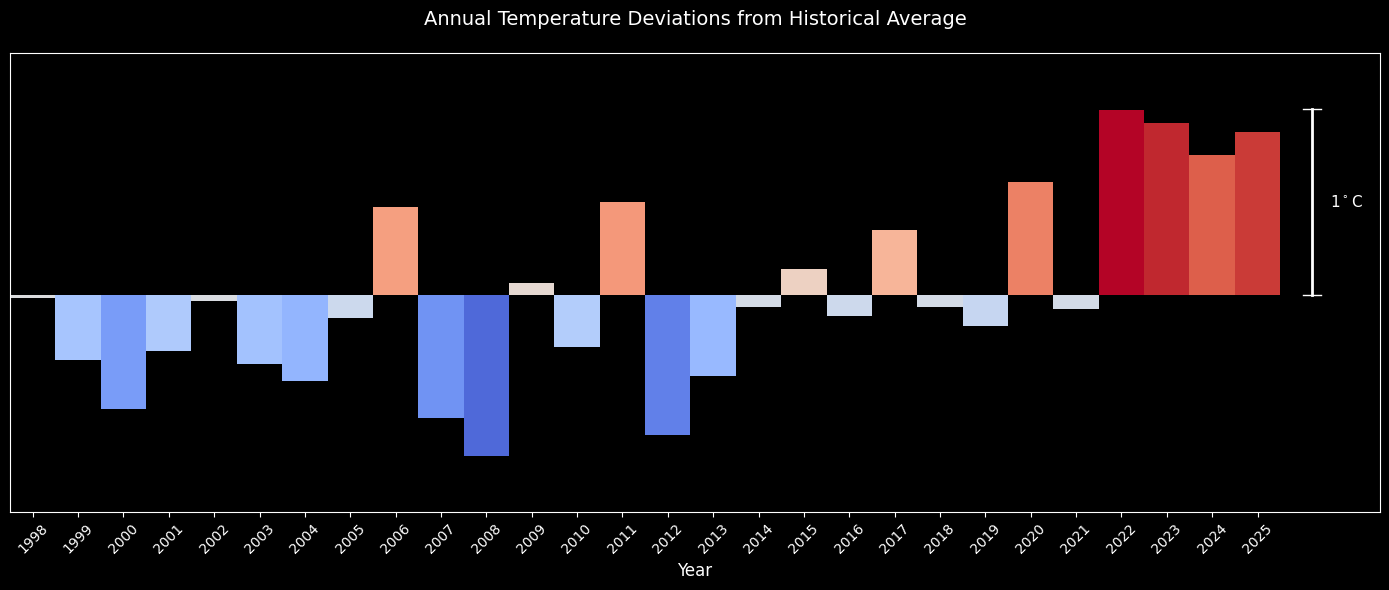

In [18]:
# 4. Calculate the annual average temperature across all stations and months
annual_trend = df_long.groupby("year")["temperature"].mean().reset_index()

# 5. Calculate the overall historical baseline mean across all years
overall_mean = annual_trend["temperature"].mean()

# 6. Calculate the deviation (height of the bars from the baseline)
annual_trend["anomaly"] = annual_trend["temperature"] - overall_mean

# 7. Set up color mapping based on the size of the anomaly
max_abs_anomaly = annual_trend["anomaly"].abs().max()
norm = mcolors.Normalize(vmin=-max_abs_anomaly, vmax=max_abs_anomaly)
cmap = plt.get_cmap("coolwarm")
colors = [cmap(norm(val)) for val in annual_trend["anomaly"]]

# 8. Plot the bar graph
plt.figure(figsize=(14, 6))

# Set width=1.0 to eliminate the spaces between bars completely
bars = plt.bar(
    annual_trend["year"],
    annual_trend["anomaly"],
    bottom=overall_mean,
    color=colors,
    edgecolor="none",
    width=1.0,
)

# 9. Formatting the plot
plt.title(
    "Annual Temperature Deviations from Historical Average",
    fontsize=14,
    pad=20,
)
plt.xlabel("Year", fontsize=12)

# Explicitly style the baseline line at the overall mean
#plt.axhline(overall_mean, color="white", linestyle="-", linewidth=1.0, alpha=0.9)

# Position variables for the vertical 1°C scale indicator
# Placed just past the final bar on the right side
scale_x = annual_trend["year"].max() + 1.2
scale_y_bottom = overall_mean
scale_y_top = overall_mean + 1.0

# Draw the vertical indicator line
plt.plot(
    [scale_x, scale_x],
    [scale_y_bottom, scale_y_top],
    color="white",
    linestyle="-",
    linewidth=2,
)

# Add small cap ticks to the top and bottom of the vertical line
plt.plot(
    [scale_x - 0.2, scale_x + 0.2],
    [scale_y_bottom, scale_y_bottom],
    color="white",
    linewidth=1,
)
plt.plot(
    [scale_x - 0.2, scale_x + 0.2],
    [scale_y_top, scale_y_top],
    color="white",
    linewidth=1,
)

# Label the scale bar
plt.text(
    x=scale_x + 0.4,
    y=(scale_y_bottom + scale_y_top) / 2,
    s="1$^\circ$C",
    color="white",
    va="center",
    ha="left",
    fontsize=11,
)

# Clean up axes: Remove the traditional Y-axis text labels and tick marks
plt.ylabel("")
plt.gca().get_yaxis().set_ticks([])

# Ensure all year labels show up nicely on the X-axis
plt.xticks(annual_trend["year"], rotation=45)

# Adjust plot boundaries to display the right-side scale bar cleanly
plt.xlim(annual_trend["year"].min() - 0.5, scale_x + 1.5)

# Adjust y-limits slightly to give the bars breathing room
plt.ylim(
    min(annual_trend["temperature"].min() - 0.3, overall_mean - 0.5),
    max(annual_trend["temperature"].max() + 0.3, overall_mean + 1.3),
)

plt.tight_layout()
plt.show()

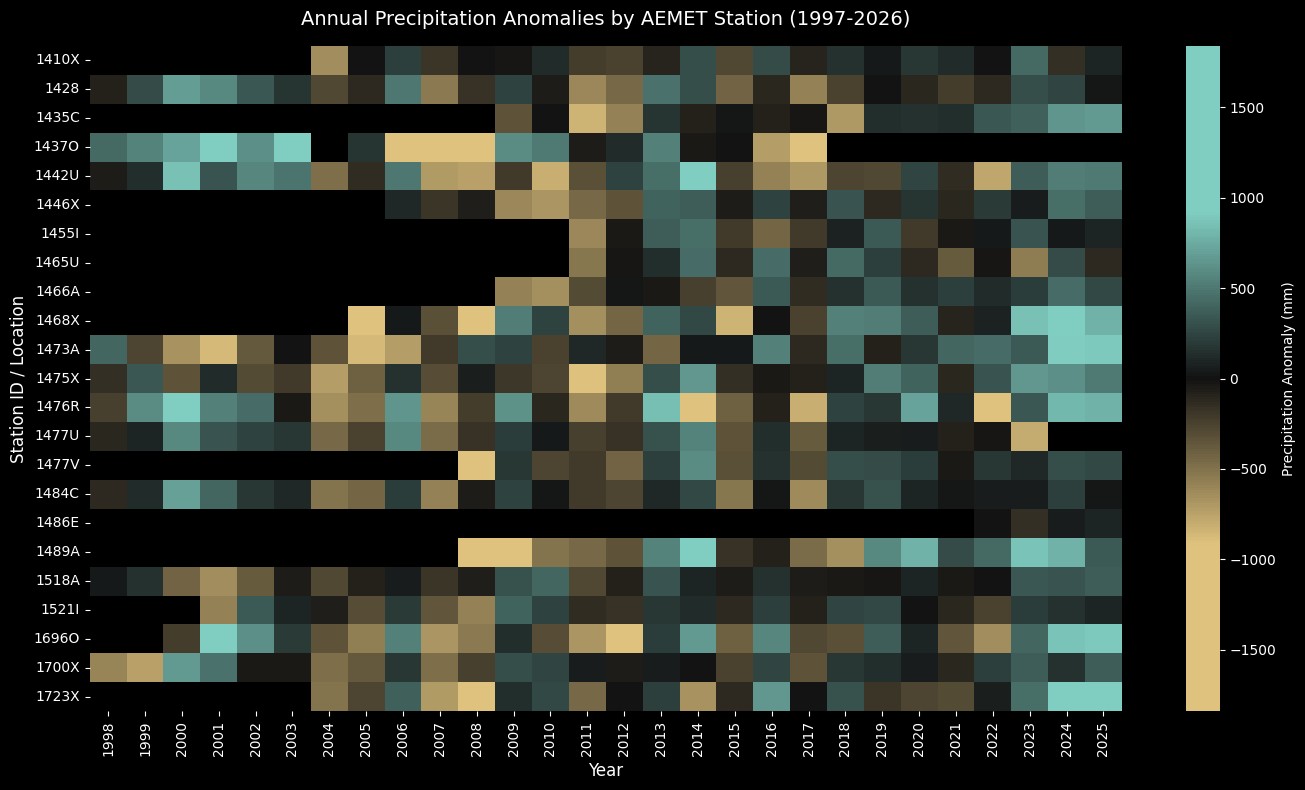

In [26]:
# Assuming the file structure (year, station_id, Jan-Dec) remains identical
df = pd.read_excel("/galicia_precip_1997_2026_v3.xlsx")

# 2. Filter for the requested years
df = df[(df["year"] >= 1998) & (df["year"] <= 2025)]

# 3. Reshape from wide format (months as columns) to long format
month_columns = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
df_long = pd.melt(
    df,
    id_vars=["year", "station_id"],
    value_vars=month_columns,
    var_name="month",
    value_name="precipitation",
)

# 4. Calculate TOTAL annual precipitation for each station in each year
# Note: We use .sum() here because annual rainfall is cumulative, unlike temperature.
annual_station_precip = (
    df_long.groupby(["station_id", "year"])["precipitation"]
    .sum()
    .reset_index()
)

# 5. Calculate the baseline historical average annual precipitation FOR EACH STATION
station_baseline = (
    annual_station_precip.groupby("station_id")["precipitation"]
    .mean()
    .reset_index()
)
station_baseline.rename(
    columns={"precipitation": "baseline_precip"}, inplace=True
)

# Merge the baseline back into our annual data
plot_data = pd.merge(annual_station_precip, station_baseline, on="station_id")

# 6. Calculate the anomaly (departure from that station's own average in mm)
plot_data["anomaly"] = plot_data["precipitation"] - plot_data["baseline_precip"]

# 7. Pivot the data: Station ID on Y-axis, Years on X-axis
pivot = plot_data.pivot_table(
    values="anomaly", index="station_id", columns="year"
)

# Colour gradient logic (dry to wet)
# Deep Brown (Very Dry) -> Light Tan -> Dark/Muted Center -> Teal/Green -> Deep Blue-Green (Very Wet)
gradient_colors = ["#dfc27d", "#dfc27d","#121212", "#80cdc1", "#80cdc1"]

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "dry_wet_diverging", gradient_colors
)

# 8. Plot the heatmap
plt.figure(figsize=(14, 8))

# Find the maximum absolute deviation to ensure 0 stays in the dark center
max_val = plot_data["anomaly"].abs().max()

sns.heatmap(
    pivot,
    cmap=custom_cmap,
    center=0,
    vmin=-max_val,
    vmax=max_val,
    cbar_kws={"label": "Precipitation Anomaly (mm)"},
    linecolor="#222222",  # Subtle dark borders between grid squares
)

plt.title(
    "Annual Precipitation Anomalies by AEMET Station (1997-2026)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Station ID / Location", fontsize=12)

plt.tight_layout()
plt.show()